## Exposure Time Calculator for SDSU MLO Spectrograph

In this notebook, we will develop a rudimentary exposure time calculator that either a) given an exposure time, outputs the SNR or b) given a SNR, outputs the exposure time.

In [2]:
#import libs:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import h, c
from astropy.table import Table
from scipy.interpolate import interp1d
from scipy import integrate


### Basic setup:

Use equation: $$m - m_{zp} = -2.5 \log_{10}([\mathrm{counts}])$$ to get counts.

For SNR: $$SNR = \frac{S_{obj}}{\sqrt{S_{obj} + S_{sky} + S_{dark} + R^2}}$$

This translates to the CCD equation: $$SNR = \frac{S_{obj}\sqrt{Q_e t} }{\sqrt{S_{obj} + n_{pix}(S_{sky} + (\frac{S_{dark}}{Q_e}) + (\frac{R^2}{Q_e t}))}}$$

$Q_e$: quantum efficiency

$S_{obj}$: object counts (phot/sec)

$S_{sky}$: sky counts (background??) (phot/sec/pix)

$S_{dark}$: dark current (elec/sec/pix)

$n_{pix}$: pixel size of object

$R$: readout noise (elec/pix)

$t$: **exposure time**

*probably use algebra to reverse this equation?*

In [3]:
def get_counts_from_mag(mag, mag_zp):
    """Given an apparent magnitude and zero-point magnitude, output the number of counts asscociated with the magnitude."""
    counts = np.power(10, (mag_zp - mag)/2.5)

    return counts

def basic_get_SNR(exp_time, mag, mag_zp, ob_size, sky_noise, dark_current, quant_eff, read_noise):
    """Predicts the SNR given an exposure time.
    
    Parameters:

    exp_time: exposure time (s)

    mag: apparent magnitude of object

    mag_zp: zero-point magnitude

    ob_size: size of object, in pixels

    sky_noise: background counts per pixel (phot/s/pix)

    dark_current: dark current (elec/s/pix)

    quant_eff: quantum efficiency (between 0 and 1)

    read_noise: time independent detector noise (elec/pix)
    """
    s_ob = get_counts_from_mag(mag, mag_zp)

    numerator = s_ob * np.sqrt(quant_eff * exp_time)
    
    denominator = np.sqrt(s_ob + ob_size * (sky_noise + (dark_current/quant_eff) + (read_noise**2/(quant_eff * exp_time))))

    snr = numerator/denominator
    
    return snr

In [4]:
def basic_get_exptime(SNR, mag, mag_zp, ob_size, sky_noise, dark_current, quant_eff, read_noise):
    """Predicts the best exposure time to achieve a desired SNR.
    
    Parameters:

    SNR: signal to noise ratio

    mag: apparent magnitude of object

    mag_zp: zero-point magnitude

    ob_size: size of object, in pixels

    sky_noise: background counts per pixel (phot/s/pix)

    dark_current: dark current (elec/s/pix)

    quant_eff: quantum efficiency (between 0 and 1)

    read_noise: time independent detector noise (elec/pix)
    """

    s_ob = get_counts_from_mag(mag, mag_zp)

    C = s_ob/ob_size + sky_noise + dark_current/quant_eff

    exp_time = (C * ob_size * SNR**2 * quant_eff + np.sqrt((SNR**2 * quant_eff * ob_size * C)**2 + 4 * (s_ob * quant_eff)**2 * (read_noise**2 * ob_size * SNR**2)))/(2 * (s_ob * quant_eff)**2)

    return exp_time

In [5]:
#create some mock values to test:

mag = 16
mag_zp = 24
exp_time = 30.0

pix_rad = 5
ob_size = np.pi * pix_rad**2

dark_current = 0.01
sky_noise = 5.0
quant_eff = 0.75
read_noise = 5.0

basic_get_SNR(exp_time, mag, mag_zp, ob_size, sky_noise, dark_current, quant_eff, read_noise)

np.float64(165.4001836679808)

In [6]:
des_SNR = 100
basic_get_exptime(des_SNR, mag, mag_zp, ob_size, sky_noise, dark_current, quant_eff, read_noise)

np.float64(11.691419511902296)

### Better approach: Calculate $S_{ob}$ NOT from zero point:

Use the equation: $$S_{obj}​=∫f_λ​(λ)\frac{λ}{hc}​A_{tel}​T_{total}​(λ)dλ$$

where $f_{\lambda}$ is the flux density. To transform a magnitude into this quantity, use: $$f_{\nu}​=3631\mathrm{Jy}×10^{−m/2.5}$$ then 
$$f_{\lambda} = f_{\nu}\frac{c}{\lambda^2}$$

$T_{total}$ is the total throughput, which is defined as: $$T_{total}​=T_{fiber}​T_{grating}​T_{lenses}​T_{detector}​​$$

$A_{tel}$ is the telescope area.

**Must get rid of Quantum efficiency in CCD equation if using this approach**

In [7]:
plot_waves_qe = [400, 450, 500, 550, 600, 650, 700, 750, 800, 850] #waves inferred from qe plot
qe_vals = [0.72, 0.91, 0.89, 0.84, 0.75, 0.60, 0.46, 0.34, 0.27, 0.22] # qe  % values inferred from qe plot 

qe_curve = interp1d(plot_waves_qe, qe_vals, kind='cubic', bounds_error=False, fill_value='extrapolate') #allow extrapolation, but need to set bounds in functions later

def get_qe(wave_nm):
    """takes wavelength in nm and returns QE value at that wavelength.""" 
    return float(qe_curve(wave_nm))

get_qe(450)

0.91

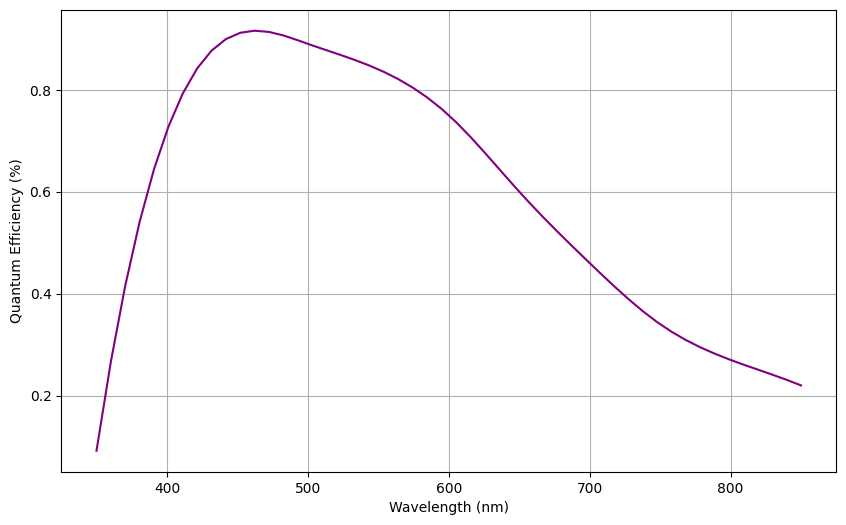

In [8]:
qe_wave = np.linspace(350, 850)
qe_curve(qe_wave)
plt.figure(figsize=(10, 6))
plt.plot(qe_wave, qe_curve(qe_wave), c='purple')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Quantum Efficiency (%)')
plt.grid();

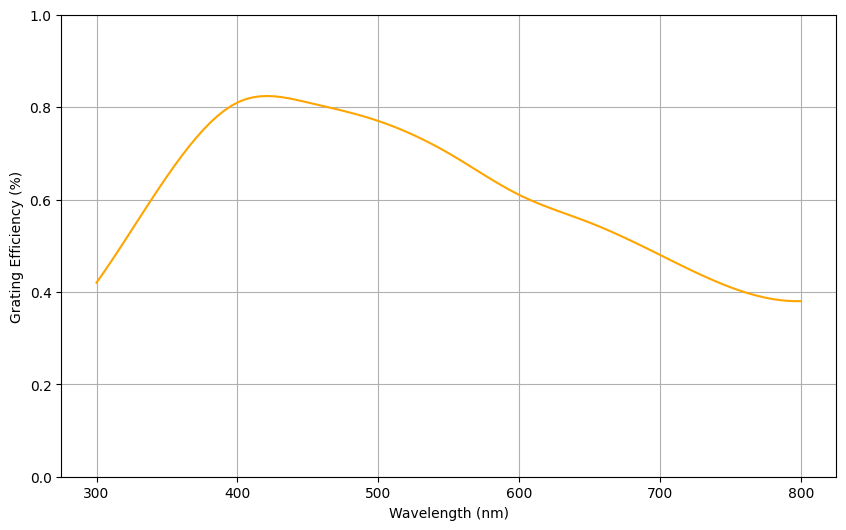

In [9]:
plot_waves_grat = [300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800]
gr_vals = [0.42, 0.65, 0.81, 0.81, 0.77, 0.70, 0.61, 0.55, 0.48, 0.41, 0.38]
gr_curve = interp1d(plot_waves_grat, gr_vals, kind='cubic', bounds_error=False, fill_value='extrapolate')

def get_gr(wave_nm):
    """takes wavelength in nm and returns grating efficiency value at that wavelength.""" 
    return float(gr_curve(wave_nm))

gr_wave = np.linspace(300, 800, 100)
plt.figure(figsize=(10, 6))
plt.plot(gr_wave, gr_curve(gr_wave), c = 'orange')
plt.ylim(0, 1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Grating Efficiency (%)')
plt.grid();

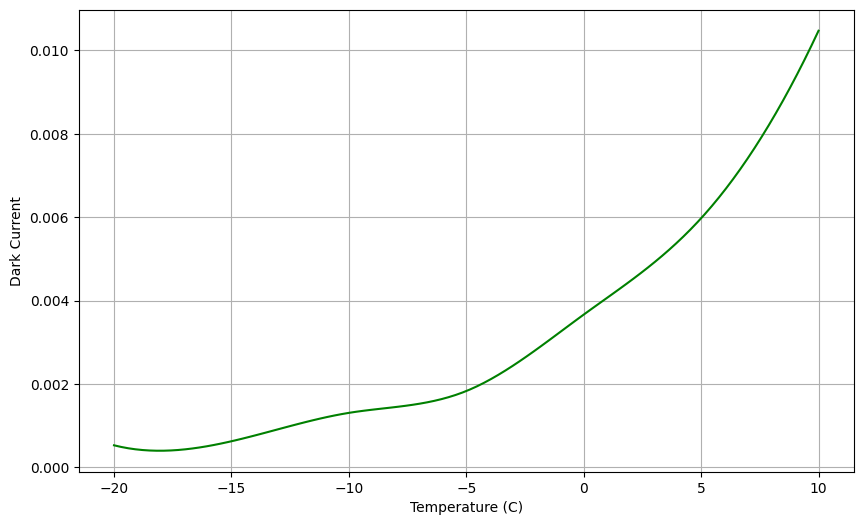

In [10]:
plot_temps_dc = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
dc_vals = [0.00053145, 0.00062832, 0.001309,
            0.0018326, 0.0036652, 0.0059756, 0.010472, 0.019111, 0.036913]
dc_curve = interp1d(plot_temps_dc, dc_vals, kind='cubic', bounds_error=False, fill_value=0.0) #not necessary to extrapolate here

def get_dc(temp_C):
    """takes temperature in C  and returns dark current value at that temperature.""" 
    return float(dc_curve(temp_C))


dc_temps = np.linspace(-20, 10, 100)
plt.figure(figsize=(10, 6))
plt.plot(dc_temps, dc_curve(dc_temps), c = 'green')
plt.xlabel('Temperature (C)')
plt.ylabel('Dark Current')
plt.grid();

In [11]:
def get_tp(detec, grat, fiber=0.995, lens=0.99):
    """Obtains the total instrument throughput from individual components"""

    total_tp = fiber * grat * lens * detec
    
    return total_tp

In [12]:
tp = get_tp(0.8, 0.6)

In [13]:
def get_flux_density(wavelength, mag_ab):
    """Determines the wavelength-dependent flux-density with a given AB-mag
    
    Wavelength is in nanometers.
    """

    wavelength = wavelength * u.nm

    f_ab = 3631 * u.Jy * np.power(10, (-mag_ab/2.5))
    f_lambda = f_ab.to(u.W/(u.m**2 * u.nm), equivalencies = u.spectral_density(wavelength))
    
    return f_lambda

get_flux_density(500,18)

<Quantity 2.74730542e-18 W / (nm m2)>

In [14]:
def get_sob(wavelength, mag_ab, throughput, t_diam = 1250):


    f_lam = get_flux_density(wavelength, mag_ab)

    t_area = np.pi * (((t_diam * u.mm).to(u.m))/2)**2

    s_ob = f_lam * (wavelength * u.nm)/(h * c) * t_area * throughput

    return s_ob.to(1/(u.s * u.nm))

get_sob(500, 18, tp)

<Quantity 4.01245002 1 / (nm s)>

In [115]:
def get_sob_for_wave_array(wavelength, mag_ab, fiber=0.995, lens=0.99, t_diam = 1250):

    s_obs = []
    grats = []
    detecs = []
    for wave in wavelength:
        grat = np.clip(get_gr(wave) - 0.1, 0, 1) #account for efficiency loss due to instrument design
        detec = get_qe(wave)
        grats.append(grat)
        detecs.append(detec)
        tp = get_tp(detec, grat, fiber, lens)

        f_lam = get_flux_density(wave, mag_ab)

        t_area = np.pi * (((t_diam * u.mm).to(u.m))/2)**2

        s_ob = f_lam * (wave * u.nm)/(h * c) * t_area * tp

        s_obs.append(s_ob.to(1/(u.s * u.nm)).value)
    return s_obs, grats, detecs

In [16]:
x, y, z = get_sob_for_wave_array(np.arange(400, 900, 0.5), 18)
np.mean(z)

np.float64(0.14201653423050475)

In [ ]:
rn_tot = (3.5+1.1)/2 #this is wrong.... assume something like 20 instead
pix_area = 6280 * 4210

rn_pp = rn_tot/pix_area
rn_pp

8.699335824621389e-08

In [ ]:
def get_SNR(exp_time, wavelength, mag, ob_size=6.5, sky_noise=5.0, dark_current=0.001309, 
            read_noise=8.70e-8, fiber=0.995, grat=0.6, lens=0.99, detec=0.8, t_diam=1250, 
            temp=-10, value_output_only=False, show_plots=True, static_tp=False, use_temp_for_dc=True):
    """
    Predicts the SNR given an exposure time.
    
    Parameters:
    -----------------------------------------------

    exp_time: exposure time (s)

    wavelength: 
    
    --For single wavelength--> int or float; wavelength at which to evaluate snr

    --For wavelength range--> tuple of length 3 following the format: (min_wavelength, max_wavelength, step_size). Wavelength range to evaluate snr with
    desired step size. 

    mag: apparent magnitude of object

    ob_size: size of object, in pixels

    sky_noise: background counts per pixel (phot/s/pix)

    dark_current: dark current (elec/s/pix)

    read_noise: time independent detector noise (elec/pix)

    fiber: fiber attenuation (default: 0.995)

    grat: grating efficiency (default: 0.6; can be wavelength-dependent [see static_tp])

    lens: transmission fraction at lenses (default: 0.99)

    detec: quantum efficiency for detector (default: 0.8; can be wavelength-dependent [see static_tp])

    t_diam: telescope diameter (mm)

    temp: detector temperature (C) (default: -10 C)

    value_output_only: if True, function only outputs either a float snr value (for single wavelength) or an astropy table of columns 
    (wave_range, object counts, snr) (for wavelength range)

    show_plots: if True, displays plots of throughput, object counts, and snr over the desired wavelength range.

    static_tp: if False, determines quantum efficiency (detec) and grating efficiency (grat) using the provided wavelength. If true, assumes static
    efficiencies across wavelength range.

    use_temp_for_dc: if True, determines the dark current based on the detector temperature.
    """

    # User-communication pipeline: makes sure all inputs are correct type and within correct range:
    if (type(wavelength) == int) or (type(wavelength) == float):
        if (wavelength < 400) or (wavelength > 900):
            raise(ValueError(f'Entered wavelength ({wavelength}) is outside the instrument range. Known range: 400-900 nm'))
        
    elif type(wavelength) == tuple:
        if len(wavelength) == 3:
            if wavelength[0] > wavelength[1]:
                raise(ValueError('Tuple must be of length (3) following the format: (min_wavelength, max_wavelength, step_size)'))
            if (wavelength[0] < 400) or (wavelength[1] > 900):
                raise(ValueError(f'Entered wavelength range ({wavelength[0]}, {wavelength[1]}) is outside the instrument range. Known range: 400-900 nm'))
        else:
            raise(ValueError('Tuple must be of length (3) following the format: (min_wavelength, max_wavelength, step_size)'))
    else:
        raise(TypeError(f"'Wavelength' must be of type int, float, or tuple, not type {type(wavelength)}"))
    
    if use_temp_for_dc:
         if (temp < -20) or (temp > 20):
            raise(ValueError(f'Entered temperature ({temp}) has no value for dark current (out of bounds). Known tempeature range: -20 to 20 C'))
         dark_current=get_dc(temp)

    
    

    #generate s_ob using a singular wavelength:
    if (type(wavelength) == int) or (type(wavelength) == float):

        if not value_output_only:
            print('Photometric parameters:\n------------------------')
            print(f'Exposure time: {exp_time} s\nWavelength: {wavelength} nm\nAB Magnitude: {mag}\nPixel Size: {ob_size} pix^2\nSky noise: {sky_noise} phot/s/pix')
            print(f'Camera temp: {temp} C\nDark current: {dark_current:.6f} e/s/pix\nRead noise: {read_noise} e/pix\nTelescope diameter: {t_diam} mm\n')

        if static_tp:
            tp = get_tp(detec, grat, fiber, lens)

        else:
            
            grat = np.clip(get_gr(wavelength) - 0.1, 0, 1) #account for efficiency loss due to instrument design
            detec = get_qe(wavelength) 
            tp = get_tp(detec, grat, fiber, lens)

        if not value_output_only:
            print('Throughput parameters:\n------------------------')
            print(f'Fiber: {fiber:.3f}\nLenses: {lens:.3f}\nGrating: {grat:.3f}\nDetector: {detec:.3f}\nTotal Throughput: {tp:.3f}')

        s_ob = get_sob(wavelength, mag, tp, t_diam).value

        numerator = s_ob * np.sqrt(exp_time)
    
        denominator = np.sqrt(s_ob + ob_size * (sky_noise + dark_current + (read_noise**2/exp_time)))

        snr = numerator/denominator

        if value_output_only:
            return snr
        else:
            print(f'\nSNR with entered parameters: {snr}')

    else:
        wave_min, wave_max, bin_step = wavelength
        wave_arr = np.arange(wave_min, wave_max + bin_step, bin_step) # makes array of wavelengths with step size bin_step
        wave_centers = 0.5 * (wave_arr[:-1] + wave_arr[1:]) #used for plotting later

        s_obs, grats, detecs = get_sob_for_wave_array(wave_arr, mag, fiber, lens, t_diam)
        s_obs = np.array(s_obs) #convert all outputs to numpy arrays for later
        grats = np.array(grats)
        detecs= np.array(detecs)
        s_ob_broadband = integrate.simpson(s_obs, x=wave_arr) #integrates over all wavelength values to get full broadband counts
        
        #UI pipeline:
        if not value_output_only:
            print('Photometric parameters:\n------------------------')
            print(f'Exposure time: {exp_time} s\nAB Magnitude: {mag}\nPixel Size: {ob_size} pix^2\nSky noise: {sky_noise} phot/s/pix')
            print(f'Camera temp: {temp} C\nDark current: {dark_current:.6f} e/s/pix\nRead noise: {read_noise} e/pix\nTelescope diameter: {t_diam} mm\n')

            print('Throughput parameters:\n------------------------')
            print(f'Fiber: {fiber:.3f}\nLenses: {lens:.3f}\nGrating Average: {np.mean(grats):.3f}\nDetector Average: {np.mean(detecs):.3f}\n')

            print('Integration parameters:\n------------------------')
            print(f'Minimum Wavelength: {wave_min} nm\nMaximum Wavelength: {wave_max} nm\nStep size: {bin_step} nm')
            print(f'Total Object Counts: {s_ob_broadband}\n')

        #initialize table:
        t = Table(names=('Wave bin (nm)', 'S_ob', 'SNR'), dtype=(str, 'f4', 'f4'))
        if not value_output_only:
            print('Binned SNR:\n')

        # iterate over all bins
        for i in range(wave_min, wave_max, bin_step):
            i_next = i + bin_step #get the upper limit of each bin
            wave_bin = (wave_arr >= i) & (wave_arr < i_next) # mask for each bin

            s_ob_bin = integrate.simpson(s_obs[wave_bin], x=wave_arr[wave_bin])

            numerator = s_ob_bin * np.sqrt(exp_time)
    
            denominator = np.sqrt(s_ob_bin + ob_size * (sky_noise + dark_current + (read_noise**2/exp_time)))

            snr_bin = numerator/denominator

            t.add_row((f'{i}-{i_next}', s_ob_bin, snr_bin))

        if value_output_only:
            return t
        else:
            t.pprint(max_lines=-1)
            if show_plots:
                fig, ax, = plt.subplots(1, 3, figsize=(20, 6))
                ax[0].plot(wave_arr, grats*detecs*lens*fiber, c='darkgreen')
                ax[0].set_xlabel('Wavelength (nm)')
                ax[0].set_ylabel('Throughput')
                ax[0].grid()

                ax[1].plot(wave_centers, t['S_ob'], c='gold')
                ax[1].set_xlabel('Wavelength (nm)')
                ax[1].set_ylabel('Object Counts')
                ax[1].grid()

                ax[2].plot(wave_centers, t['SNR'], c='navy')
                ax[2].set_xlabel('Wavelength (nm)')
                ax[2].set_ylabel('SNR')
                ax[2].grid()

                plt.tight_layout
                plt.show() 

Photometric parameters:
------------------------
Exposure time: 3 s
AB Magnitude: 18
Pixel Size: 6.5 pix^2
Sky noise: 5.0 phot/s/pix
Camera temp: -10 C
Dark current: 0.001309 e/s/pix
Read noise: 8.7e-08 e/pix
Telescope diameter: 1250 mm

Throughput parameters:
------------------------
Fiber: 0.995
Lenses: 0.990
Grating Average: 0.486
Detector Average: 0.141

Integration parameters:
------------------------
Minimum Wavelength: 400 nm
Maximum Wavelength: 900 nm
Step size: 10 nm
Total Object Counts: 1233.5107428533931

Binned SNR:

Wave bin (nm)    S_ob       SNR    
------------- ---------- ----------
      400-410   55.56726  10.255371
      410-420   58.96979  10.679014
      420-430   60.71582  10.891755
      430-440  61.117775  10.940301
      440-450   60.51749 10.8677435
      450-460    59.2418  10.712358
      460-470   57.52538  10.500672
      470-480   55.50866  10.247966
      480-490   53.30251   9.966364
      490-500  51.005733    9.66717
      500-510   48.69761   9.3599

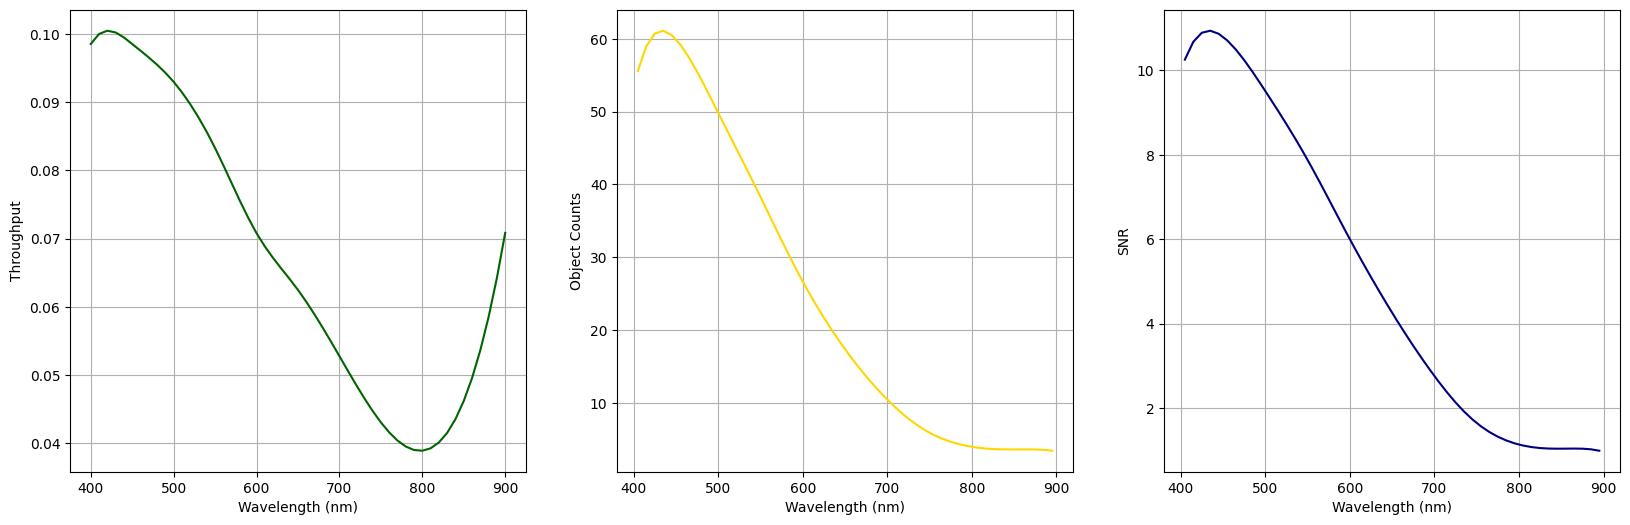

In [19]:
get_SNR(3, (400, 900, 10), 18)

In [20]:
def get_exptime(SNR, wavelength, mag, ob_size=6.5, sky_noise=5.0, dark_current=0.001309, 
            read_noise=8.70e-8, fiber=0.995, grat=0.6, lens=0.99, detec=0.8, t_diam=1250, 
            temp=-10, value_output_only=False, show_plots=True, static_tp=False, use_temp_for_dc=True):
    """
    Predicts the SNR given an exposure time.
    
    Parameters:
    -----------------------------------------------

    SNR: desired signal to noise ratio

    wavelength: 
    
    --For single wavelength--> int or float; wavelength at which to evaluate snr

    --For wavelength range--> tuple of length 3 following the format: (min_wavelength, max_wavelength, step_size). Wavelength range to evaluate snr with
    desired step size. 

    mag: apparent magnitude of object

    ob_size: size of object, in pixels

    sky_noise: background counts per pixel (phot/s/pix)

    dark_current: dark current (elec/s/pix)

    read_noise: time independent detector noise (elec/pix)

    fiber: fiber attenuation (default: 0.995)

    grat: grating efficiency (default: 0.6; can be wavelength-dependent [see static_tp])

    lens: transmission fraction at lenses (default: 0.99)

    detec: quantum efficiency for detector (default: 0.8; can be wavelength-dependent [see static_tp])

    t_diam: telescope diameter (mm)

    temp: detector temperature (C) (default: -10 C)

    value_output_only: if True, function only outputs either a float exp_time value (for single wavelength) or an astropy table of columns 
    (wave_range, object counts, exp_time) (for wavelength range)

    show_plots: if True, displays plots of throughput, object counts, and exp_time over the desired wavelength range.

    static_tp: if False, determines quantum efficiency (detec) and grating efficiency (grat) using the provided wavelength. If true, assumes static
    efficiencies across wavelength range.

    use_temp_for_dc: if True, determines the dark current based on the detector temperature.
    """

    # User-communication pipeline: makes sure all inputs are correct type and within correct range:
    if (type(wavelength) == int) or (type(wavelength) == float):
        if (wavelength < 400) or (wavelength > 900):
            raise(ValueError(f'Entered wavelength ({wavelength}) is outside the instrument range. Known range: 400-900 nm'))
        
    elif type(wavelength) == tuple:
        if len(wavelength) == 3:
            if wavelength[0] > wavelength[1]:
                raise(ValueError('Tuple must be of length (3) following the format: (min_wavelength, max_wavelength, step_size)'))
            if (wavelength[0] < 400) or (wavelength[1] > 900):
                raise(ValueError(f'Entered wavelength range ({wavelength[0]}, {wavelength[1]}) is outside the instrument range. Known range: 400-900 nm'))
        else:
            raise(ValueError('Tuple must be of length (3) following the format: (min_wavelength, max_wavelength, step_size)'))
    else:
        raise(TypeError(f"'Wavelength' must be of type int, float, or tuple, not type {type(wavelength)}"))
    
    if use_temp_for_dc:
         if (temp < -20) or (temp > 20):
            raise(ValueError(f'Entered temperature ({temp}) has no value for dark current (out of bounds). Known tempeature range: -20 to 20 C'))
         dark_current=get_dc(temp)

    
    

    #generate s_ob using a singular wavelength:
    if (type(wavelength) == int) or (type(wavelength) == float):

        if not value_output_only:
            print('Photometric parameters:\n------------------------')
            print(f'Desired SNR: {SNR}\nWavelength: {wavelength} nm\nAB Magnitude: {mag}\nPixel Size: {ob_size} pix^2\nSky noise: {sky_noise} phot/s/pix')
            print(f'Camera temp: {temp} C\nDark current: {dark_current:.6f} e/s/pix\nRead noise: {read_noise} e/pix\nTelescope diameter: {t_diam} mm\n')

        if static_tp:
            tp = get_tp(detec, grat, fiber, lens)

        else:
            
            grat = np.clip(get_gr(wavelength) - 0.1, 0, 1) #account for efficiency loss due to instrument design
            detec = get_qe(wavelength) 
            tp = get_tp(detec, grat, fiber, lens)

        if not value_output_only:
            print('Throughput parameters:\n------------------------')
            print(f'Fiber: {fiber:.3f}\nLenses: {lens:.3f}\nGrating: {grat:.3f}\nDetector: {detec:.3f}\nTotal Throughput: {tp:.3f}')

        s_ob = get_sob(wavelength, mag, tp, t_diam).value

        C = s_ob/ob_size + sky_noise + dark_current

        exp_time = (C * ob_size * SNR**2 + np.sqrt((SNR**2 * ob_size * C)**2 + 4 * (s_ob)**2 * (read_noise**2 * ob_size * SNR**2)))/(2 * (s_ob)**2)

        if value_output_only:
            return exp_time
        else:
            print(f'\nRequired exposure time for desired SNR: {exp_time:.4f} s')

    else:
        wave_min, wave_max, bin_step = wavelength
        wave_arr = np.arange(wave_min, wave_max + bin_step, bin_step) # makes array of wavelengths with step size bin_step
        wave_centers = 0.5 * (wave_arr[:-1] + wave_arr[1:]) #used for plotting later

        s_obs, grats, detecs = get_sob_for_wave_array(wave_arr, mag, fiber, lens, t_diam)
        s_obs = np.array(s_obs) #convert all outputs to numpy arrays for later
        grats = np.array(grats)
        detecs= np.array(detecs)
        s_ob_broadband = integrate.simpson(s_obs, x=wave_arr) #integrates over all wavelength values to get full broadband counts
        
        #UI pipeline:
        if not value_output_only:
            print('Photometric parameters:\n------------------------')
            print(f'Desired SNR: {SNR}\nAB Magnitude: {mag}\nPixel Size: {ob_size} pix^2\nSky noise: {sky_noise} phot/s/pix')
            print(f'Camera temp: {temp} C\nDark current: {dark_current:.6f} e/s/pix\nRead noise: {read_noise} e/pix\nTelescope diameter: {t_diam} mm\n')

            print('Throughput parameters:\n------------------------')
            print(f'Fiber: {fiber:.3f}\nLenses: {lens:.3f}\nGrating Average: {np.mean(grats):.3f}\nDetector Average: {np.mean(detecs):.3f}\n')

            print('Integration parameters:\n------------------------')
            print(f'Minimum Wavelength: {wave_min} nm\nMaximum Wavelength: {wave_max} nm\nStep size: {bin_step} nm')
            print(f'Total Object Counts: {s_ob_broadband}\n')

        #initialize table:
        t = Table(names=('Wave bin (nm)', 'S_ob', 'Exp. Time (s)'), dtype=(str, 'f4', 'f4'))
        if not value_output_only:
            print('Binned Exposure Time:\n')

        # iterate over all bins
        for i in range(wave_min, wave_max, bin_step):
            i_next = i + bin_step #get the upper limit of each bin
            wave_bin = (wave_arr >= i) & (wave_arr <= i_next) # mask for each bin

            s_ob_bin = integrate.simpson(s_obs[wave_bin], x=wave_arr[wave_bin])

            
            C = s_ob_bin/ob_size + sky_noise + dark_current

            exp_time_bin = (C * ob_size * SNR**2 + np.sqrt((SNR**2 * ob_size * C)**2 + 4 * (s_ob_bin)**2 * (read_noise**2 * ob_size * SNR**2)))/(2 * (s_ob_bin)**2)

            t.add_row((f'{i}-{i_next}', s_ob_bin, exp_time_bin))

        if value_output_only:
            return t
        else:
            t.pprint(max_lines=-1)
            if show_plots:
                fig, ax, = plt.subplots(1, 3, figsize=(20, 6))
                ax[0].plot(wave_arr, grats*detecs*lens*fiber, c='darkgreen')
                ax[0].set_xlabel('Wavelength (nm)')
                ax[0].set_ylabel('Throughput')
                ax[0].grid()

                ax[1].plot(wave_centers, t['S_ob'], c='gold')
                ax[1].set_xlabel('Wavelength (nm)')
                ax[1].set_ylabel('Object Counts')
                ax[1].grid()

                ax[2].plot(wave_centers, t['Exp. Time (s)'], c='red')
                ax[2].set_xlabel('Wavelength (nm)')
                ax[2].set_ylabel('Exposure Time (s)')
                ax[2].grid()

                plt.tight_layout
                plt.show() 

In [29]:
wave_min = (6000 * u.AA).to(u.nm)
wave_max = (7000 * u.AA).to(u.nm)
wave_bin = (50 * u.AA).to(u.nm)

print(wave_min, wave_max, wave_bin)

600.0 nm 700.0 nm 5.0 nm


In [ ]:
get_SNR()

Photometric parameters:
------------------------
Desired SNR: 2
AB Magnitude: 18
Pixel Size: 6.5 pix^2
Sky noise: 5.0 phot/s/pix
Camera temp: -10 C
Dark current: 0.001309 e/s/pix
Read noise: 8.7e-08 e/pix
Telescope diameter: 1250 mm

Throughput parameters:
------------------------
Fiber: 0.995
Lenses: 0.990
Grating Average: 0.516
Detector Average: 0.270

Integration parameters:
------------------------
Minimum Wavelength: 400 nm
Maximum Wavelength: 800 nm
Step size: 2 nm
Total Object Counts: 1197.257175283401

Binned Exposure Time:

Wave bin (nm)    S_ob    Exp. Time (s)
------------- ---------- -------------
      400-402  10.784734     1.4888852
      402-404  10.979992     1.4428805
      404-406  11.159563     1.4025865
      406-408 11.3237505     1.3673297
      408-410  11.472898     1.3365427
      410-412  11.607381     1.3097444
      412-414  11.727609     1.2865244
      414-416  11.834017     1.2665317
      416-418  11.927065     1.2494637
      418-420  12.007234     1.2

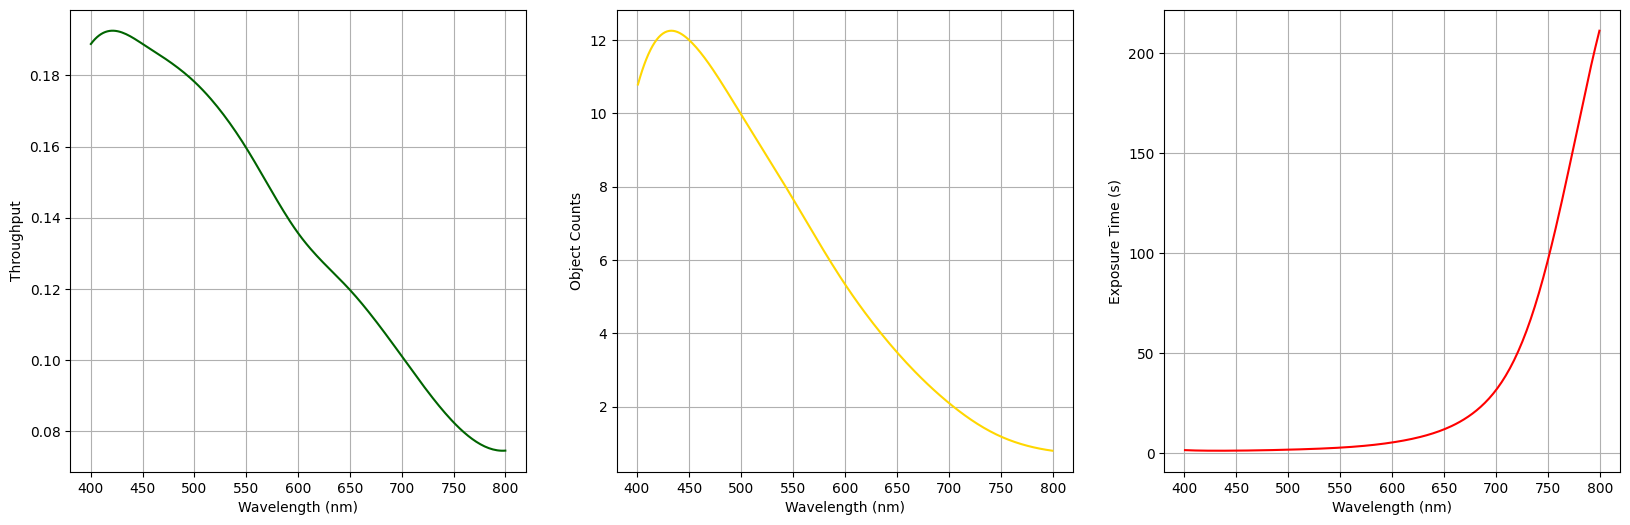

In [ ]:
get_exptime(2, (400, 800, 2), 18)

### Part III: Compute SNR utilizing a spectrum file:

Things that need to change:

1. $S_{obj}$ is computed with the spectrum file, not with a given AB mag. This means $f_{\lambda}$ is already given.
2. Bins must be centered at specific wavelength intervals (use a list for this)
3. $n_{total}$ is now $n_{\lambda}n_{spacial}$ 


Other notes:
1. Changing the SNR equation to total counts (rather than rates) makes it super easy to think about it conceptually: *dark current and sky noise are variances and the denominator computes the noise, which is just the square root of the variance.*
2. Read noise is just a standard deviation. It is useful to know the variance of this, so use $R^2$. It is then even more useful to get the total read variance which is just $n_{total}R^2$. The 'read noise' is then $\sqrt{n_{total}R^2}$

In [35]:
datadir = '/home/Master_Control/MLO-Spectrograph/data/SNIa_max_z0p05.txt'

In [66]:
def load_spectrum(dir, z):
    """loads a spectrum file and deredshifts it"""
    spec = np.genfromtxt(dir, dtype=[('wave', float), ('flux', float)])

    #de-redshift spectrum:
    a = 1/(1 + z)
    spec['wave'] *= a
    return spec

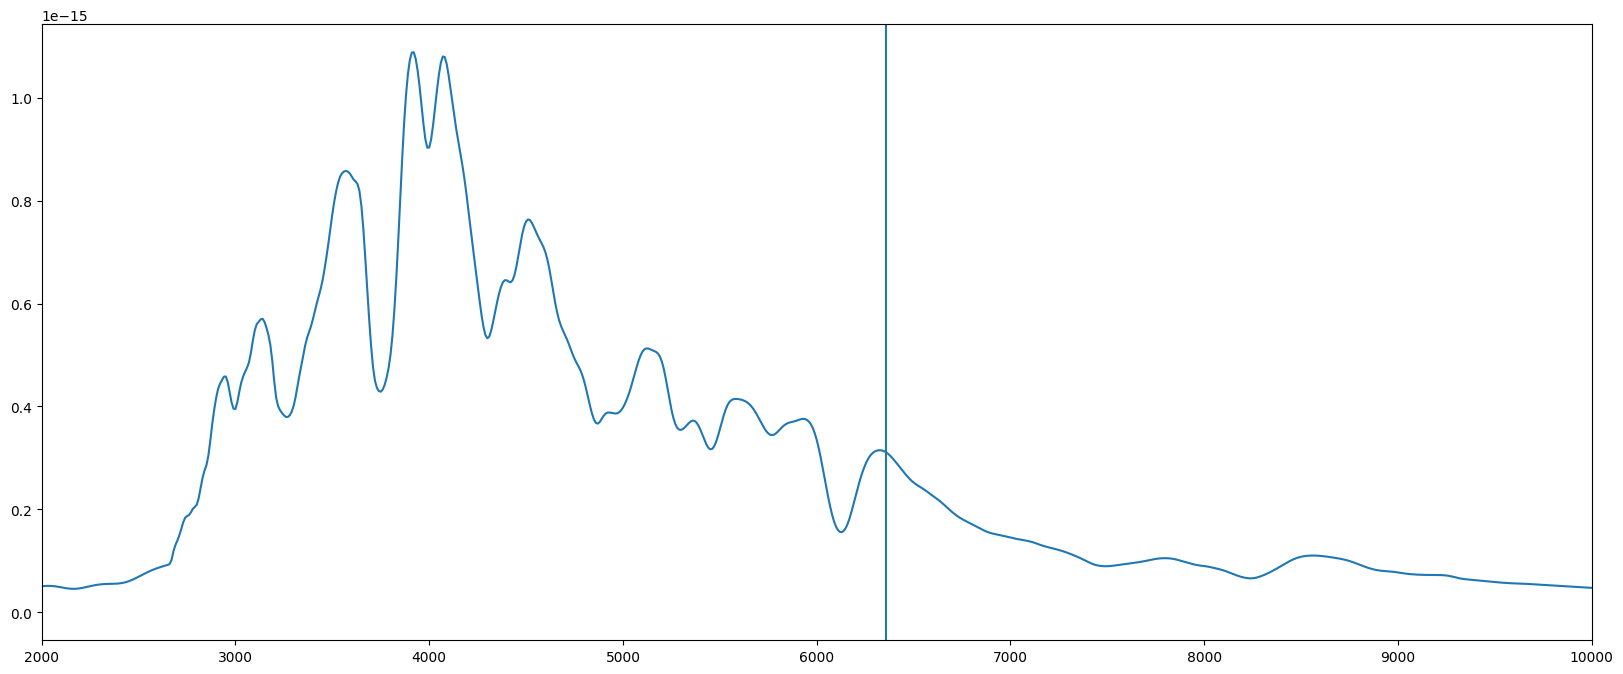

In [67]:
spec = load_spectrum(datadir, 0.05)
plt.figure(figsize=(20, 8))
plt.plot(spec['wave'], spec['flux'])
plt.xlim(2000, 10000)
plt.axvline(6355)

$$S_{obj}​=∫f_λ​(λ)\frac{λ}{hc}​A_{tel}​T_{total}​(λ)dλ$$


In [107]:
spec['wave'] /=10

In [111]:
center = 600
binsize=50

wave_min = center - binsize/20
wave_max = center + binsize/20

w = (spec['wave'] >= wave_min) & (spec['wave'] <= wave_max)
spec[w]

array([(598., 3.57958380e-16), (599., 3.47894457e-16),
       (600., 3.35072477e-16), (601., 3.19613379e-16),
       (602., 3.01900316e-16)], dtype=[('wave', '<f8'), ('flux', '<f8')])

In [83]:
spec['flux'][spec['wave']==spec['wave'][0]]

array([1.73677349e-19])

In [126]:
def get_sob_from_spec(spectrum, fiber=0.995, lens=0.99, t_diam = 1250):

    s_obs = []
    grats = []
    detecs = []
    for wave in spectrum['wave']:
        grat = np.clip(get_gr(wave) - 0.1, 0, 1) #account for efficiency loss due to instrument design
        detec = get_qe(wave)
        grats.append(grat)
        detecs.append(detec)
        tp = get_tp(detec, grat, fiber, lens)

        f_lam = spectrum['flux'][spectrum['wave']==wave][0] * u.erg / (u.s * u.cm**2 * u.AA)

        t_area = np.pi * (((t_diam * u.mm).to(u.m))/2)**2

        s_ob = f_lam * (wave * u.nm)/(h * c) * t_area * tp

        s_obs.append(s_ob.to(1/(u.s * u.nm)).value)
    return s_obs, grats, detecs

In [152]:
def get_SNR_from_spectrum(exp_time, datadir,z, wave_centers, binsize, dispersion, spacial_aperture, sky_noise=5.0, dark_current=0.001309, read_noise_e=2.3, fiber=0.995, 
        lens=0.99, t_diam=1250, temp=-10, value_output_only=False, show_plots=True, use_temp_for_dc=True):
    """determines the SNR at a given exposure time and set of wavelength bins using an observed spectrum"""

    if use_temp_for_dc:
         if (temp < -20) or (temp > 20):
            raise(ValueError(f'Entered temperature ({temp}) has no value for dark current (out of bounds). Known tempeature range: -20 to 20 C'))
         dark_current=get_dc(temp)
    
    wave_centers = np.array(wave_centers) #make np array for easy use later

    #load spectrum file:
    spec = load_spectrum(datadir, z)
    spec['wave'] /= 10 #convert to nm to allign with tp figures

    print(f"Determining SNR using spectrum located at '{datadir}'....\n")
    print('Binning Parameters:\n------------------------')
    print(f'Bin centers: {wave_centers} nm\nBin size: {binsize} nm\n')

    
    #determine total number of pixels:
    n_wave = binsize/dispersion

    n_spacial = spacial_aperture #might need to change this later, good placeholder for now.

    n_total = n_wave * n_spacial

    # determine readout noise:
    read_noise_var = read_noise_e**2 * n_total

    #Evalutate dark current/sky noise counts given pixel size/ exposure time:
    dark_counts = dark_current * n_total * exp_time
    sky_counts = sky_noise * n_total * exp_time

    print('Photometric parameters:\n------------------------')
    print(f'Exposure time: {exp_time} s\nDispersion: {dispersion} nm/pix\nSpacial Aperture: {spacial_aperture} pix\nTotal Native Pixels: {n_total} pix\nSky noise: {sky_counts} phot ({sky_noise} phot/s/pix)')
    print(f'Camera temp: {temp} C\nDark current: {dark_counts:.6f} e ({dark_current} e/s/pix)\nRead noise: {np.sqrt(read_noise_var):.6f} e/pix\nTelescope diameter: {t_diam} mm')

    t = Table(names=('Wave Center (nm)', 'S_ob', 'SNR'), dtype=(str, 'f4', 'f4'))
    #evaluate SNR for each center:
    for center in wave_centers:
        print(f'\n{center} nm:')
        #determine object counts:
        wave_min = center - binsize/2
        wave_max = center + binsize/2
        w = (spec['wave'] >= wave_min) & (spec['wave'] <= wave_max) #constrain spectrum values to bin
        s_obs, grats, detecs = get_sob_from_spec(spec[w], fiber, lens, t_diam)

        s_ob_bin = integrate.simpson(s_obs)

        #obtain total source counts in given exposure:
        source_counts = s_ob_bin * exp_time
        
        snr_bin = source_counts/np.sqrt(source_counts + sky_counts + dark_counts + read_noise_var) #changed this to be more intuitive

        print('    Throughput parameters:\n    ------------------------')
        print(f'    Fiber: {fiber:.3f}\n    Lenses: {lens:.3f}\n    Grating Average: {np.mean(grats):.3f}\n    Detector Average: {np.mean(detecs):.3f}\n')
        print(f'    Object Counts: {s_ob_bin}\n    SNR: {snr_bin}')

In [153]:
get_SNR_from_spectrum(7200, datadir, 0.05, [600, 700], 5, 0.1, 4)


Determining SNR using spectrum located at '/home/Master_Control/MLO-Spectrograph/data/SNIa_max_z0p05.txt'....

Binning Parameters:
------------------------
Bin centers: [600 700] nm
Bin size: 5 nm

Photometric parameters:
------------------------
Exposure time: 7200 s
Dispersion: 0.1 nm/pix
Spacial Aperture: 4 pix
Total Native Pixels: 200.0 pix
Sky noise: 7200000.0 phot (5.0 phot/s/pix)
Camera temp: -10 C
Dark current: 1884.960000 e (0.001309 e/s/pix)
Read noise: 32.526912 e/pix
Telescope diameter: 1250 mm

600 nm:
    Throughput parameters:
    ------------------------
    Fiber: 0.995
    Lenses: 0.990
    Grating Average: 0.510
    Detector Average: 0.750

    Object Counts: 18.626477840054118
    SNR: 49.51107894760087

700 nm:
    Throughput parameters:
    ------------------------
    Fiber: 0.995
    Lenses: 0.990
    Grating Average: 0.380
    Detector Average: 0.460

    Object Counts: 4.330950722171793
    SNR: 11.593717402468123
